# Angular Distribution Sample Comparison (c0-Normalized)

This notebook compares **pre-generated ENDF samples** with EXFOR data and the original JEFF evaluation,
showing **c0-normalized angular distributions** that scale all ENDF curves to match EXFOR experimental data.

## Normalization Approach
Instead of energy folding, we use **c0-based normalization**:
1. Fit EXFOR data with Legendre polynomials to extract c0 (isotropic component = total XS / 4π)
2. Scale all ENDF differential cross sections by the EXFOR-derived c0
3. This aligns ENDF curves with experimental data at the isotropic level

## Expected Directory Structure for Samples
```
<SAMPLES_BASE_DIR>/
  endf/
    evaluation/
      26-Fe-56g_evaluation.endf  (or similar)
    nominal/
      26-Fe-56g_nominal.endf  (or similar)
    0001/
      26-Fe-56g_0001.endf
    0002/
      26-Fe-56g_0002.endf
    ...
```

## 1. Configuration Parameters

In [ ]:
# ============================================================================
# USER CONFIGURABLE PARAMETERS
# ============================================================================

# Path to directory containing pre-generated ENDF samples
# Expected structure: <base_dir>/endf/NNNN/26-Fe-56g_NNNN.endf
# Special directories: evaluation/, nominal/ for reference files
SAMPLES_BASE_DIR = '/share_snc/snc/JuanMonleon/ENDF_samples'

#"/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files"  

# Target energy to analyze (MeV)
TARGET_ENERGY_MEV = 1.0

# Original JEFF evaluation for reference
ENDF_FILE = "/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/26-Fe-56g.txt"

# EXFOR configuration (same as reference notebook)
EXFOR_DB_PATH = '/share_snc/snc/JuanMonleon/EXFOR/x4_iron_angular.db'
TARGET_ZAIDS = [26056, 26000]  # Fe-56 + natural iron
MT_NUMBER = 2  # Elastic scattering

# Supplementary JSON files (experiments not in database)
SUPPLEMENTARY_JSON_FILES = [
    '/share_snc/snc/JuanMonleon/EXFOR/data_v1/27673002.json',  # Gkatis (2025)
]

# Experiment exclusion
EXCLUDE_EXPERIMENTS = ["20743002", "32246002"]  

# - "20743002" - Cierjacks (1978)
# - "32246002" - Tostkii (1957)


# Minimum relative uncertainty floor
MIN_RELATIVE_UNCERTAINTY = 0.03  # 3% minimum uncertainty floor

# Target masses for LAB->CM conversion
M_PROJ_U = 1.008665  # Neutron mass (u)
M_TARG_U = 55.93494  # Fe-56 mass (u)

# TOF parameters for energy bin computation
DELTA_T_NS = 5.0      # Time resolution (ns)
FLIGHT_PATH_M = 27.037  # Flight path (m)

# ============================================================================
# c0-NORMALIZATION APPROACH
# ============================================================================
# We fit EXFOR data with Legendre polynomials: y(μ) = Σ c_l P_l(μ)
# The c0 coefficient represents the isotropic component = σ_total / (4π)
# All ENDF curves are normalized by this c0 to align with experimental data.
# ============================================================================

# ============================================================================
# DISPLAY PARAMETERS
# ============================================================================
print(f"Configuration:")
print(f"  Samples directory: {SAMPLES_BASE_DIR}")
print(f"  Target energy: {TARGET_ENERGY_MEV} MeV")
print(f"  Reference ENDF: {ENDF_FILE}")
print(f"  TOF parameters: L={FLIGHT_PATH_M} m, dt={DELTA_T_NS} ns")
print(f"  Normalization: c0-based (from EXFOR Legendre fit)")

Configuration:
  Samples directory: /share_snc/snc/JuanMonleon/ENDF_samples/endf
  Target energy: 1.0 MeV
  Reference ENDF: /mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/26-Fe-56g.txt
  TOF parameters: L=27.037 m, dt=5.0 ns
  Normalization: c0-based (from EXFOR Legendre fit)


## 2. Imports and Setup

In [2]:
import sys
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add kika to path if needed
_kika_path = Path().absolute().parent.parent.parent.parent
if str(_kika_path) not in sys.path:
    sys.path.insert(0, str(_kika_path))

# Import kika modules
import kika
from kika.endf import read_endf
import kika.exfor as exfor
from kika.exfor import read_all_exfor

# Import angular distribution function (for computing f(μ) from ENDF coefficients)
from kika.utils.energy_folding import endf_angular_distribution

# Import scripts modules
from scripts.exfor_utils import (
    build_exfor_cache_from_objects,
    filter_exfor_with_energy_bin,
    EnergyBinInfo,
)
from scripts.resample_AD import (
    compute_energy_resolution_tof as compute_sigma_E,
    sample_legendre_coefficients,
)

# Configure EXFOR database
exfor.configure(db_path=EXFOR_DB_PATH)

print("Imports successful!")

Imports successful!


## 3. Load Sample ENDF Files

Scan the samples directory for ENDF files, detecting:
- **evaluation/**: Special evaluation file
- **nominal/**: Special nominal file  
- **NNNN/**: Numbered MC sample files

In [3]:
# Scan for all sample files
sample_pattern = f"{SAMPLES_BASE_DIR}/endf/*/26-Fe-56g*.endf"
all_sample_files = sorted(glob.glob(sample_pattern))

print(f"Looking for samples with pattern: {sample_pattern}")
print(f"Found {len(all_sample_files)} total files")

# Separate special files from numbered samples
evaluation_file = None
nominal_file = None
numbered_sample_files = []

for f in all_sample_files:
    parent_dir = Path(f).parent.name
    if parent_dir == "evaluation":
        evaluation_file = f
        print(f"  Found evaluation file: {f}")
    elif parent_dir == "nominal":
        nominal_file = f
        print(f"  Found nominal file: {f}")
    elif parent_dir.isdigit() and len(parent_dir) == 4:
        numbered_sample_files.append(f)

print(f"\nNumbered MC samples: {len(numbered_sample_files)}")
if len(numbered_sample_files) > 0:
    print(f"First few: {[Path(f).parent.name for f in numbered_sample_files[:3]]}")
    
if len(numbered_sample_files) == 0 and evaluation_file is None and nominal_file is None:
    print("\nWARNING: No sample files found!")
    print("Please check SAMPLES_BASE_DIR and ensure the directory structure is:")
    print("  <base_dir>/endf/NNNN/26-Fe-56g_NNNN.endf")
    print("  <base_dir>/endf/evaluation/26-Fe-56g_evaluation.endf (optional)")
    print("  <base_dir>/endf/nominal/26-Fe-56g_nominal.endf (optional)")

Looking for samples with pattern: /share_snc/snc/JuanMonleon/ENDF_samples/endf/endf/*/26-Fe-56g*.endf
Found 0 total files

Numbered MC samples: 0

Please check SAMPLES_BASE_DIR and ensure the directory structure is:
  <base_dir>/endf/NNNN/26-Fe-56g_NNNN.endf
  <base_dir>/endf/evaluation/26-Fe-56g_evaluation.endf (optional)
  <base_dir>/endf/nominal/26-Fe-56g_nominal.endf (optional)


In [4]:
# Load first available sample to determine energy grid and find closest energy
first_file = evaluation_file or nominal_file or (numbered_sample_files[0] if numbered_sample_files else None)

if first_file:
    print(f"Reading first sample to determine energy grid: {Path(first_file).name}")
    first_sample = read_endf(first_file, mf_numbers=4)
    mt_data = first_sample.files[4].sections[MT_NUMBER]
    
    # Get energy grid
    sample_energies_ev = np.array(mt_data.legendre_energies)
    sample_energies_mev = sample_energies_ev / 1e6
    
    # Find closest energy to target
    target_idx = np.argmin(np.abs(sample_energies_mev - TARGET_ENERGY_MEV))
    closest_energy_mev = sample_energies_mev[target_idx]
    
    print(f"Sample energy grid: {len(sample_energies_mev)} points")
    print(f"Energy range: [{sample_energies_mev.min():.4f}, {sample_energies_mev.max():.4f}] MeV")
    print(f"\nTarget energy: {TARGET_ENERGY_MEV} MeV")
    print(f"Closest grid energy: {closest_energy_mev:.6f} MeV (index {target_idx})")
    
    distance_kev = abs(closest_energy_mev - TARGET_ENERGY_MEV) * 1000
    if distance_kev < 0.001:
        print(f"  -> Target is ON the sample energy grid")
    else:
        print(f"  -> Distance to target: {distance_kev:.2f} keV")
else:
    closest_energy_mev = TARGET_ENERGY_MEV
    target_idx = 0
    print("No sample files to analyze.")

No sample files to analyze.


In [5]:
# Load evaluation and nominal files separately
evaluation_coeffs = None
evaluation_degree = None
nominal_coeffs = None

if evaluation_file:
    print(f"Loading evaluation file...")
    endf_eval = read_endf(evaluation_file, mf_numbers=4)
    mt_eval = endf_eval.files[4].sections[MT_NUMBER]
    evaluation_coeffs = np.array(mt_eval.legendre_coefficients[target_idx])
    evaluation_degree = len(evaluation_coeffs)
    print(f"  Evaluation Legendre order: L = {evaluation_degree}")
    print(f"  Coefficients: {evaluation_coeffs[:4]}..." if len(evaluation_coeffs) > 4 else f"  Coefficients: {evaluation_coeffs}")

if nominal_file:
    print(f"Loading nominal file...")
    endf_nom = read_endf(nominal_file, mf_numbers=4)
    mt_nom = endf_nom.files[4].sections[MT_NUMBER]
    nominal_coeffs = np.array(mt_nom.legendre_coefficients[target_idx])
    print(f"  Nominal Legendre order: L = {len(nominal_coeffs)}")
    print(f"  Coefficients: {nominal_coeffs[:4]}..." if len(nominal_coeffs) > 4 else f"  Coefficients: {nominal_coeffs}")

In [6]:
# Load all numbered samples and extract coefficients at target energy
sample_coeffs_list = []

if len(numbered_sample_files) > 0:
    print(f"Loading {len(numbered_sample_files)} numbered sample files...")
    
    for i, filepath in enumerate(numbered_sample_files):
        endf_sample = read_endf(filepath, mf_numbers=4)
        mt_data = endf_sample.files[4].sections[MT_NUMBER]
        
        # Get Legendre coefficients at target index
        # These are ENDF format: [a1, a2, ..., aNL] where a0=1 implicit
        coeffs = np.array(mt_data.legendre_coefficients[target_idx])
        sample_coeffs_list.append(coeffs)
        
        if (i + 1) % 100 == 0 or i == len(numbered_sample_files) - 1:
            print(f"  Loaded {i + 1}/{len(numbered_sample_files)} samples")
    
    # Convert to array
    # Pad to same length if needed (in case samples have different max L)
    max_len = max(len(c) for c in sample_coeffs_list)
    sample_coeffs_array = np.zeros((len(sample_coeffs_list), max_len))
    for i, c in enumerate(sample_coeffs_list):
        sample_coeffs_array[i, :len(c)] = c
    
    print(f"\nLoaded {len(sample_coeffs_array)} samples")
    print(f"Coefficient array shape: {sample_coeffs_array.shape}")
    print(f"Max Legendre order: L = {max_len}")
else:
    sample_coeffs_array = None
    print("No numbered samples to load.")

No numbered samples to load.


## 4. Load Original JEFF Evaluation

Read the reference ENDF file and extract the original Legendre coefficients.

In [7]:
print(f"Reading reference ENDF file: {ENDF_FILE}")

# Read ENDF file
endf_ref = read_endf(ENDF_FILE)
mf4_ref = endf_ref.get_file(4)
mt_ref = mf4_ref.sections.get(MT_NUMBER)

print(f"MF4/MT{MT_NUMBER} type: {type(mt_ref).__name__}")

# Extract energy grid and coefficients
ref_energies_ev = np.array(mt_ref.legendre_energies)
ref_energies_mev = ref_energies_ev / 1e6
ref_coeffs_list = mt_ref.legendre_coefficients

print(f"Reference energy grid: {len(ref_energies_mev)} points")
print(f"Energy range: [{ref_energies_mev.min():.4f}, {ref_energies_mev.max():.4f}] MeV")

# Find closest energy to target
ref_target_idx = np.argmin(np.abs(ref_energies_mev - TARGET_ENERGY_MEV))
ref_closest_energy_mev = ref_energies_mev[ref_target_idx]

print(f"\nTarget energy: {TARGET_ENERGY_MEV} MeV")
print(f"Closest reference grid energy: {ref_closest_energy_mev:.6f} MeV (index {ref_target_idx})")

# Get reference ENDF coefficients at this energy
original_endf_coeffs = np.array(ref_coeffs_list[ref_target_idx])  # [a1, a2, ..., aNL]
print(f"\nReference ENDF coefficients (a1 to a{len(original_endf_coeffs)}):")
for i, a in enumerate(original_endf_coeffs, start=1):
    print(f"  a{i} = {a:+.6f}")

Reading reference ENDF file: /mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/26-Fe-56g.txt


/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:90: UserWarning: Skipping MF sections without parsers: [2, 3, 6, 8, 10, 12, 14, 33]. Only parsing: [1, 4, 34]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")


MF4/MT2 type: MF4MTMixed
Reference energy grid: 3960 points
Energy range: [0.0000, 45.0000] MeV

Target energy: 1.0 MeV
Closest reference grid energy: 1.000000 MeV (index 2376)

Reference ENDF coefficients (a1 to a6):
  a1 = +0.027196
  a2 = +0.200071
  a3 = +0.071880
  a4 = +0.024492
  a5 = +0.007355
  a6 = +0.011466


## 5. Load and Filter EXFOR Data

Load EXFOR data and filter for the target energy bin.

In [8]:
print("Loading EXFOR data from database...")

# Load EXFOR data
exfor_dict = read_all_exfor(
    target=TARGET_ZAIDS,
    mt=MT_NUMBER,
    source="database",
    group_by_energy=False,
    supplementary_json_files=SUPPLEMENTARY_JSON_FILES,
    exclude_experiments=EXCLUDE_EXPERIMENTS,
)

# Convert to cache format
exfor_objects = list(exfor_dict.values())
exfor_cache, sorted_exfor_energies = build_exfor_cache_from_objects(
    exfor_objects, 
    exclude_experiments=EXCLUDE_EXPERIMENTS,
)

print(f"Loaded {len(exfor_objects)} EXFOR datasets")
print(f"Unique energies: {len(sorted_exfor_energies)}")
print(f"Energy range: [{min(sorted_exfor_energies):.4f}, {max(sorted_exfor_energies):.4f}] MeV")
if EXCLUDE_EXPERIMENTS:
    print(f"Excluded experiments: {EXCLUDE_EXPERIMENTS}")

Loading EXFOR data from database...
Loaded 118 EXFOR datasets
Unique energies: 8796
Energy range: [0.0350, 96.0000] MeV
Excluded experiments: ['20743002', '32246002']


In [9]:
# Compute energy bin parameters
# Use sigma_E from TOF parameters
sigma_E_mev = compute_sigma_E(
    E_mev=closest_energy_mev,
    delta_t_ns=DELTA_T_NS,
    flight_path_m=FLIGHT_PATH_M,
)

# Compute bin boundaries from reference ENDF grid
if ref_target_idx > 0:
    bin_lower = (ref_energies_mev[ref_target_idx - 1] + ref_closest_energy_mev) / 2
else:
    bin_lower = 0.0

if ref_target_idx < len(ref_energies_mev) - 1:
    bin_upper = (ref_closest_energy_mev + ref_energies_mev[ref_target_idx + 1]) / 2
else:
    bin_upper = float('inf')

# Create EnergyBinInfo object
bin_info = EnergyBinInfo(
    index=ref_target_idx,
    energy_ev=ref_energies_ev[ref_target_idx],
    energy_mev=ref_closest_energy_mev,
    sigma_E_mev=sigma_E_mev,
    bin_lower_mev=bin_lower,
    bin_upper_mev=bin_upper,
)

print(f"Energy bin for E = {bin_info.energy_mev:.6f} MeV:")
print(f"  Bin boundaries: [{bin_info.bin_lower_mev:.6f}, {bin_info.bin_upper_mev:.6f}] MeV")
print(f"  Bin width: {(bin_info.bin_upper_mev - bin_info.bin_lower_mev)*1000:.2f} keV")
print(f"  Energy resolution (sigma_E): {bin_info.sigma_E_mev*1000:.2f} keV")

Energy bin for E = 1.000000 MeV:
  Bin boundaries: [0.999500, 1.000500] MeV
  Bin width: 1.00 keV
  Energy resolution (sigma_E): 5.12 keV


In [10]:
# Filter EXFOR data for the energy bin
print(f"Filtering EXFOR data using ENERGY_BIN method")
print(f"  Bin: [{bin_info.bin_lower_mev:.4f}, {bin_info.bin_upper_mev:.4f}] MeV")

exfor_df, experiments_info, kernel_weights, diagnostics = filter_exfor_with_energy_bin(
    exfor_cache=exfor_cache,
    sorted_energies=sorted_exfor_energies,
    bin_lower_mev=bin_info.bin_lower_mev,
    bin_upper_mev=bin_info.bin_upper_mev,
    target_energy_mev=bin_info.energy_mev,
    m_proj_u=M_PROJ_U,
    m_targ_u=M_TARG_U,
    dedupe_per_experiment=True,
    exclude_experiments=EXCLUDE_EXPERIMENTS,
    min_relative_uncertainty=MIN_RELATIVE_UNCERTAINTY,
    normalize_by_n_points=True,
    max_experiment_weight_fraction=0.5,
)

# Add experiment_id column for plotting
if not exfor_df.empty and 'experiment_id' not in exfor_df.columns:
    exfor_df['experiment_id'] = exfor_df['entry'] + '/' + exfor_df['subentry']

print(f"\nFiltered EXFOR data:")
print(f"  Total data points: {len(exfor_df)}")
print(f"  Experiments used: {len(experiments_info)}")

if diagnostics:
    print(f"  N_eff (effective sample size): {diagnostics.n_eff:.1f}")

# Show experiment details
print(f"\nExperiments (within bin [{bin_info.bin_lower_mev:.4f}, {bin_info.bin_upper_mev:.4f}] MeV):")
for exp in experiments_info:
    author = exp.get('author', 'Unknown')
    year = exp.get('year', '????')
    n_pts = exp.get('n_points', 0)
    e_exfor = exp.get('exfor_energy_mev', 0)
    entry = exp.get('entry', '')
    subentry = exp.get('subentry', '')
    print(f"  {entry}/{subentry}: {author} ({year}) - {n_pts} points @ {e_exfor:.4f} MeV")

Filtering EXFOR data using ENERGY_BIN method
  Bin: [0.9995, 1.0005] MeV

Filtered EXFOR data:
  Total data points: 72
  Experiments used: 7
  N_eff (effective sample size): 39.7

Experiments (within bin [0.9995, 1.0005] MeV):
  10571/002: Kinney (1976) - 8 points @ 1.0000 MeV
  11519/016: Cox (1966) - 8 points @ 1.0000 MeV
  11637/007: Walt (1954) - 9 points @ 1.0000 MeV
  11638/003: Darden (1955) - 5 points @ 1.0000 MeV
  20197/006: Malmskog (1972) - 7 points @ 1.0000 MeV
  20379/003: Jacquot (1966) - 33 points @ 1.0000 MeV
  30076/004: Barnard (1968) - 2 points @ 1.0000 MeV


## 6. Fit EXFOR Data for c0 (Isotropic Component)

Fit EXFOR data with Legendre polynomials to extract c0, the isotropic component.
This c0 value will be used to normalize all ENDF differential cross sections.

In [11]:
# Determine fit degree: use evaluation degree if available, else match JEFF reference
if evaluation_degree is not None:
    fit_degree = evaluation_degree
    print(f"Using evaluation file Legendre order: L = {fit_degree}")
else:
    fit_degree = len(original_endf_coeffs)
    print(f"Using JEFF reference Legendre order: L = {fit_degree}")

# Fit EXFOR data with Legendre polynomials
print(f"\nFitting EXFOR data with Legendre polynomials (degree={fit_degree})...")

coef_df, fit_info = sample_legendre_coefficients(
    df=exfor_df,
    value_col="value",
    unc_col="unc",
    mu_col="mu",
    degree=fit_degree,
    ridge_lambda=1e-6,
    n_samples=1,
    rescale_unc_by_chi2=True,
    external_weights=kernel_weights,
)

# Extract c0 (isotropic component)
# c0 is the l=0 coefficient in dσ/dΩ(μ) = Σ c_l P_l(μ)
# Since ∫₋₁¹ P_l(μ) dμ = 2δ_{l,0}, we have σ_total = 4π × c0
c0_exfor = coef_df['c0'].values[0]  # Average dσ/dΩ (in b/sr)

print(f"\nEXFOR Legendre fit results:")
print(f"  c0 (average dσ/dΩ): {c0_exfor:.6f} b/sr")
print(f"  Implied σ_total = 4π × c0 = {4 * np.pi * c0_exfor:.4f} b")
print(f"  chi2_red: {fit_info['chi2_red']:.3f}")
print(f"  Fit degree: L = {fit_info['degree']}")
print(f"  Scale factor (Birge): {fit_info['scale_factor']:.3f}")

# Show all fitted coefficients
print(f"\nFitted coefficients (c_l for dσ/dΩ = Σ c_l P_l(μ)):")
for col in coef_df.columns:
    if col.startswith('c'):
        print(f"  {col} = {coef_df[col].values[0]:+.6f}")

Using JEFF reference Legendre order: L = 6

Fitting EXFOR data with Legendre polynomials (degree=6)...

EXFOR Legendre fit results:
  c0 (average dσ/dΩ): 0.172248 b/sr
  Implied σ_total = 4π × c0 = 2.1645 b
  chi2_red: 8.937
  Fit degree: L = 6
  Scale factor (Birge): 2.990

Fitted coefficients (c_l for dσ/dΩ = Σ c_l P_l(μ)):
  c0 = +0.172248
  c1 = +0.122027
  c2 = +0.153861
  c3 = +0.029945
  c4 = -0.010278
  c5 = -0.014748
  c6 = -0.028824


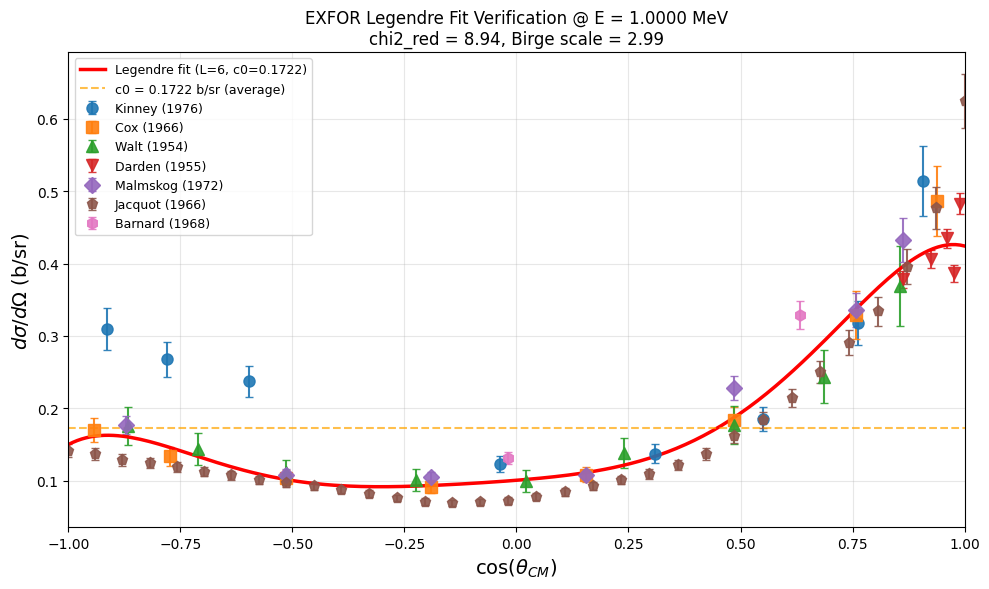


Fit quality check:
  chi2_red = 8.94 (should be ~1.0 for good fit)


In [12]:
# DIAGNOSTIC PLOT: Verify the EXFOR Legendre fit
# This plot shows the raw EXFOR data and the fitted Legendre polynomial
# to verify the fit is working correctly before using c0 for normalization.

from numpy.polynomial.legendre import legval

fig, ax = plt.subplots(figsize=(10, 6))

# Plot EXFOR data points
colors = plt.cm.tab10.colors
markers = ['o', 's', '^', 'v', 'D', 'p', 'h', '*']

if not exfor_df.empty:
    exp_ids = exfor_df['experiment_id'].unique() if 'experiment_id' in exfor_df.columns else [None]
    
    for i, exp_id in enumerate(exp_ids):
        if exp_id is not None:
            mask = exfor_df['experiment_id'] == exp_id
            df_exp = exfor_df[mask]
            exp_info = next((e for e in experiments_info 
                           if f"{e.get('entry', '')}/{e.get('subentry', '')}" == exp_id), {})
            label = f"{exp_info.get('author', exp_id)} ({exp_info.get('year', '?')})"
        else:
            df_exp = exfor_df
            label = 'EXFOR data'
        
        ax.errorbar(
            df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
            fmt=markers[i % len(markers)],
            color=colors[i % len(colors)],
            label=label,
            capsize=3,
            markersize=8,
            alpha=0.9,
        )

# Plot the fitted Legendre polynomial: y(μ) = Σ c_l P_l(μ)
mu_fit = np.linspace(-1, 1, 200)
fit_coeffs = [coef_df[f'c{i}'].values[0] for i in range(fit_degree + 1)]
y_fit = legval(mu_fit, fit_coeffs)

ax.plot(mu_fit, y_fit, 'r-', linewidth=2.5, 
        label=f'Legendre fit (L={fit_degree}, c0={c0_exfor:.4f})')

# Mark c0 level (average dσ/dΩ)
ax.axhline(c0_exfor, color='orange', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'c0 = {c0_exfor:.4f} b/sr (average)')

# Formatting
ax.set_xlabel(r'$\cos(\theta_{CM})$', fontsize=14)
ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=14)
ax.set_title(
    f'EXFOR Legendre Fit Verification @ E = {bin_info.energy_mev:.4f} MeV\n'
    f'chi2_red = {fit_info["chi2_red"]:.2f}, Birge scale = {fit_info["scale_factor"]:.2f}',
    fontsize=12
)
ax.set_xlim(-1, 1)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFit quality check:")
print(f"  chi2_red = {fit_info['chi2_red']:.2f} (should be ~1.0 for good fit)")
if fit_info['chi2_red'] > 3:
    print(f"  WARNING: High chi2_red suggests poor fit or underestimated uncertainties")

## 7. Compute c0-Normalized Differential Cross Sections

Compute dσ/dΩ for all ENDF curves, normalized by the EXFOR-derived c0.

**Key relationships:**

1. **EXFOR fit**: `dσ/dΩ(μ) = Σ c_l P_l(μ)`, where c0 is the average dσ/dΩ (in b/sr)
   
2. **Total cross section**: `σ_total = 4π × c0` (from integrating dσ/dΩ over solid angle)

3. **ENDF angular PDF**: `f(μ) = (1/2) Σ (2l+1) a_l P_l(μ)` with a0=1 (implicit)
   - This f(μ) integrates to 1 over μ ∈ [-1, 1]
   - For isotropic scattering: f(μ) = 0.5

4. **Correct formula**: 
   ```
   dσ/dΩ = σ_total × f(μ) / (2π) = (4π × c0) × f(μ) / (2π) = 2 × c0 × f(μ)
   ```

**Verification for isotropic case**: If f(μ) = 0.5, then dσ/dΩ = 2 × c0 × 0.5 = c0 ✓

In [13]:
def compute_normalized_dsigma(endf_coeffs, c0_norm, mu_grid):
    """
    Compute dσ/dΩ from ENDF coefficients, normalized by c0.

    The key relationships are:
    - ENDF: f(μ) = (1/2) Σ (2l+1) a_l P_l(μ), a0=1 (implicit)
      This is a normalized PDF that integrates to 1 over μ ∈ [-1, 1]
    - σ_total = 4π × c0 (where c0 is the average dσ/dΩ from EXFOR fit)
    - dσ/dΩ = σ_total × f(μ) / (2π) = 2 × c0 × f(μ)
    
    Parameters
    ----------
    endf_coeffs : np.ndarray
        ENDF Legendre coefficients [a1, a2, ..., aNL] (a0=1 implicit)
    c0_norm : float
        Normalization factor (c0 from EXFOR fit) = average dσ/dΩ in b/sr
    mu_grid : np.ndarray
        Cosine of scattering angle grid
    
    Returns
    -------
    dsigma : np.ndarray
        Differential cross section dσ/dΩ in b/sr
    """
    # Compute angular PDF from ENDF coefficients
    # f(μ) integrates to 1 over μ, and equals 0.5 for isotropic case
    angular_pdf = endf_angular_distribution(mu_grid, endf_coeffs)
    
    # Correct normalization: dσ/dΩ = 2 × c0 × f(μ)
    # This ensures that for isotropic scattering (f=0.5), dσ/dΩ = c0
    dsigma = 2.0 * c0_norm * angular_pdf
    
    return dsigma


# Create μ grid
mu_grid = np.linspace(-1, 1, 200)

print(f"Computing c0-normalized dσ/dΩ with c0 = {c0_exfor:.6f} b/sr")
print(f"  Formula: dσ/dΩ = 2 × c0 × f(μ)  [where f(μ) is ENDF angular PDF]")

# Compute for evaluation file (if available)
dsigma_evaluation = None
if evaluation_coeffs is not None:
    dsigma_evaluation = compute_normalized_dsigma(evaluation_coeffs, c0_exfor, mu_grid)
    print(f"  Computed evaluation curve")

# Compute for nominal file (if available)
dsigma_nominal = None
if nominal_coeffs is not None:
    dsigma_nominal = compute_normalized_dsigma(nominal_coeffs, c0_exfor, mu_grid)
    print(f"  Computed nominal curve")

# Compute for JEFF reference
dsigma_jeff = compute_normalized_dsigma(original_endf_coeffs, c0_exfor, mu_grid)
print(f"  Computed JEFF reference curve")

# Compute for all MC samples
sample_dsigma_list = []
if sample_coeffs_array is not None and len(sample_coeffs_array) > 0:
    print(f"  Computing {len(sample_coeffs_array)} MC sample curves...")
    for sample_coeffs in sample_coeffs_array:
        dsigma = compute_normalized_dsigma(sample_coeffs, c0_exfor, mu_grid)
        sample_dsigma_list.append(dsigma)
    print(f"  Done.")

# Convert to array and compute statistics
if sample_dsigma_list:
    sample_dsigma_array = np.array(sample_dsigma_list)
    mc_average_dsigma = np.mean(sample_dsigma_array, axis=0)
    mc_std_dsigma = np.std(sample_dsigma_array, axis=0)
    print(f"\nMC statistics computed from {len(sample_dsigma_array)} samples")
else:
    sample_dsigma_array = None
    mc_average_dsigma = None
    mc_std_dsigma = None

# Verify normalization: check that isotropic average matches c0
print(f"\nNormalization verification:")
print(f"  c0 (from EXFOR fit) = {c0_exfor:.6f} b/sr")
if dsigma_jeff is not None:
    avg_dsigma_jeff = np.mean(dsigma_jeff)
    print(f"  Average dσ/dΩ (JEFF) = {avg_dsigma_jeff:.6f} b/sr")
    print(f"  Ratio to c0 = {avg_dsigma_jeff/c0_exfor:.4f} (should be ~1.0)")

Computing c0-normalized dσ/dΩ with c0 = 0.172248 b/sr
  Formula: dσ/dΩ = 2 × c0 × f(μ)  [where f(μ) is ENDF angular PDF]
  Computed JEFF reference curve

Normalization verification:
  c0 (from EXFOR fit) = 0.172248 b/sr
  Average dσ/dΩ (JEFF) = 0.173440 b/sr
  Ratio to c0 = 1.0069 (should be ~1.0)


## 8. Plot: c0-Normalized Angular Distributions

Single plot showing:
- **Evaluation** (blue thick line) - if available
- **Nominal** (green thick line) - if available
- **JEFF reference** (black dashed line)
- **MC samples** (gray, semi-transparent)
- **MC average** (red solid line)
- **EXFOR data points** (colored by experiment)

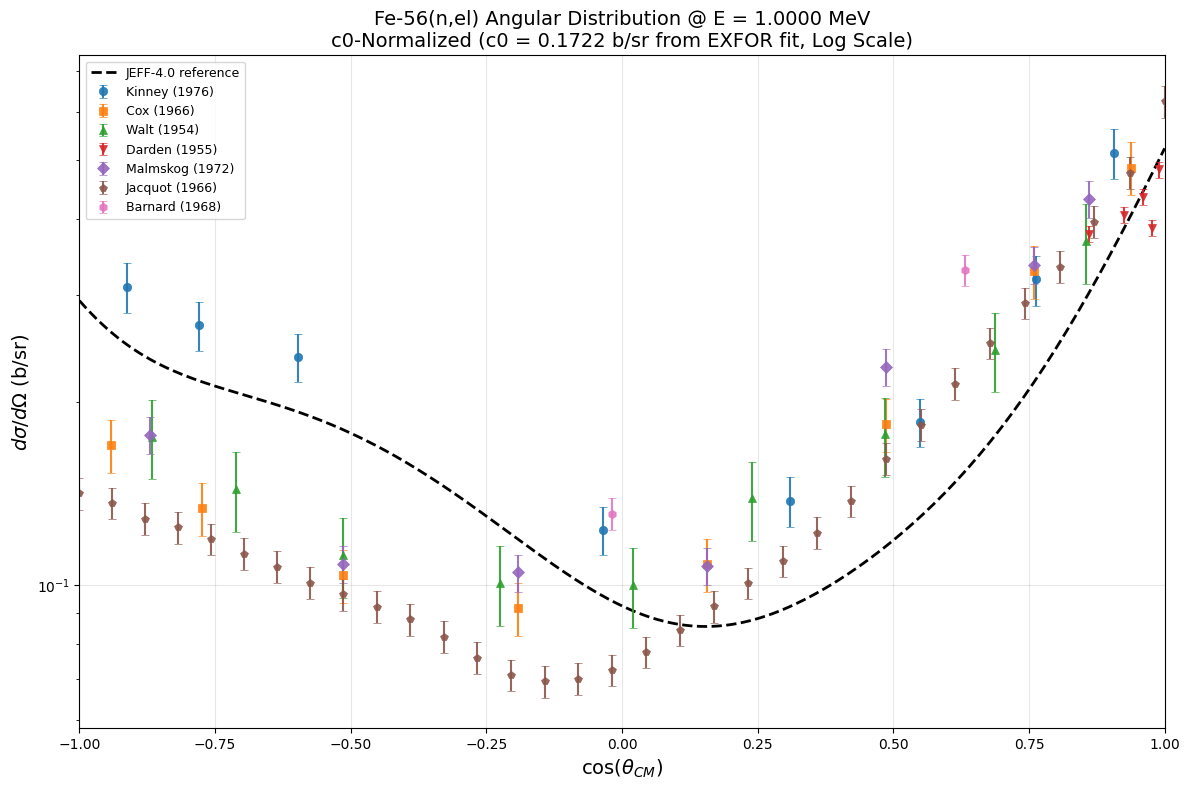

In [14]:
# LOG SCALE PLOT
fig, ax = plt.subplots(figsize=(12, 8))

# Color palette and markers for experiments
colors = plt.cm.tab10.colors
markers = ['o', 's', '^', 'v', 'D', 'p', 'h', '*', 'X', '<', '>']

# Determine alpha based on number of samples
n_samples = len(sample_dsigma_array) if sample_dsigma_array is not None else 0
if n_samples > 100:
    sample_alpha = 0.1
elif n_samples > 50:
    sample_alpha = 0.15
else:
    sample_alpha = 0.3

# 1. Plot MC sample curves (gray, semi-transparent)
if sample_dsigma_array is not None:
    for i in range(min(n_samples, 200)):  # Limit to 200 for performance
        label = 'MC samples' if i == 0 else None
        ax.plot(mu_grid, sample_dsigma_array[i], '-', color='gray', 
                alpha=sample_alpha, linewidth=0.8, label=label)

# 2. Plot MC average (red solid line)
if mc_average_dsigma is not None:
    ax.plot(mu_grid, mc_average_dsigma, 'r-', linewidth=2.5, 
            label=f'MC average (N={n_samples})')

# 3. Plot JEFF reference (black dashed line - demoted from primary)
ax.plot(mu_grid, dsigma_jeff, 'k--', linewidth=2.0, 
        label='JEFF-4.0 reference')

# 4. Plot Evaluation (blue thick solid line)
if dsigma_evaluation is not None:
    ax.plot(mu_grid, dsigma_evaluation, 'b-', linewidth=3.0, 
            label='Evaluation')

# 5. Plot Nominal (green thick solid line)
if dsigma_nominal is not None:
    ax.plot(mu_grid, dsigma_nominal, 'g-', linewidth=3.0, 
            label='Nominal')

# 6. Plot EXFOR data points (colored by experiment)
if not exfor_df.empty:
    exp_ids = exfor_df['experiment_id'].unique() if 'experiment_id' in exfor_df.columns else [None]
    
    for i, exp_id in enumerate(exp_ids):
        if exp_id is not None:
            mask = exfor_df['experiment_id'] == exp_id
            df_exp = exfor_df[mask]
            exp_info = next((e for e in experiments_info 
                           if f"{e.get('entry', '')}/{e.get('subentry', '')}" == exp_id), {})
            label = f"{exp_info.get('author', exp_id)} ({exp_info.get('year', '?')})"
        else:
            df_exp = exfor_df
            label = 'EXFOR data'
        
        ax.errorbar(
            df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
            fmt=markers[i % len(markers)],
            color=colors[i % len(colors)],
            label=label,
            capsize=3,
            markersize=6,
            alpha=0.9,
            markeredgewidth=0.5
        )

# Formatting
ax.set_xlabel(r'$\cos(\theta_{CM})$', fontsize=14)
ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=14)
ax.set_title(
    f'Fe-56(n,el) Angular Distribution @ E = {bin_info.energy_mev:.4f} MeV\n'
    f'c0-Normalized (c0 = {c0_exfor:.4f} b/sr from EXFOR fit, Log Scale)',
    fontsize=14
)
ax.set_xlim(-1, 1)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

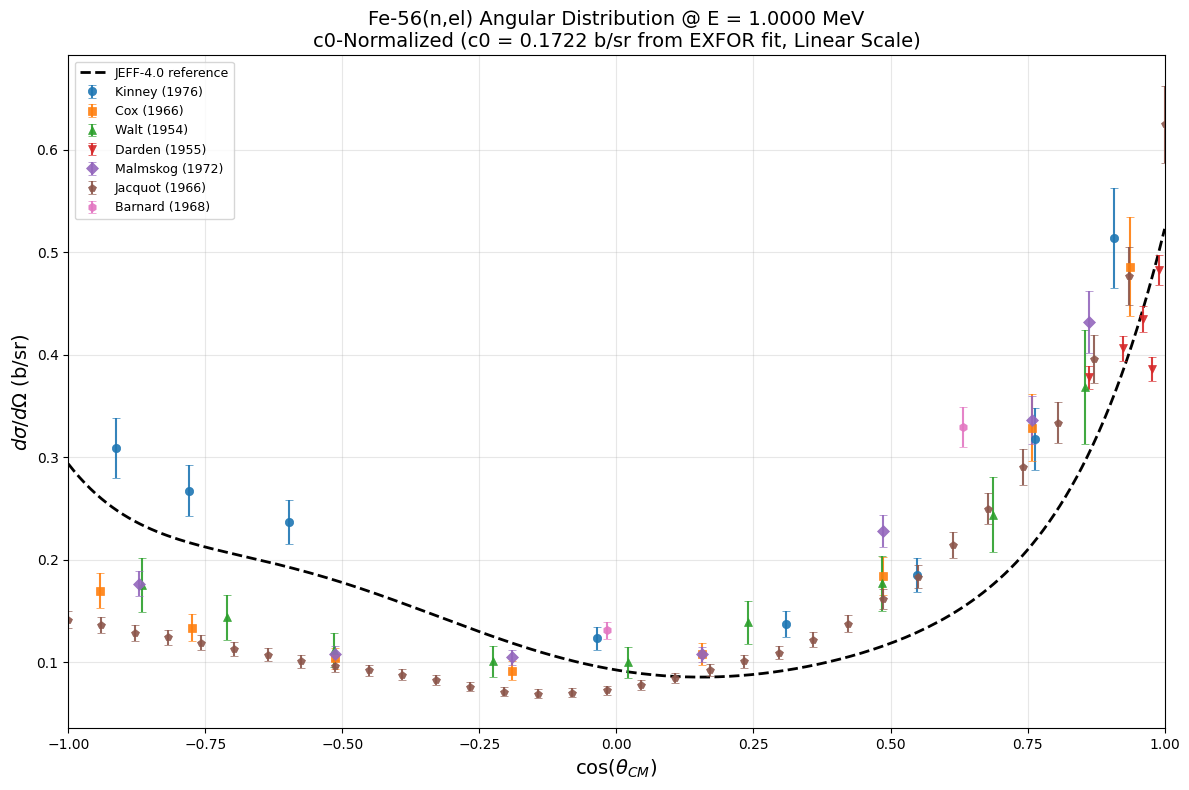

In [15]:
# LINEAR SCALE PLOT
fig, ax = plt.subplots(figsize=(12, 8))

# Color palette and markers for experiments
colors = plt.cm.tab10.colors
markers = ['o', 's', '^', 'v', 'D', 'p', 'h', '*', 'X', '<', '>']

# 1. Plot MC sample curves (gray, semi-transparent)
if sample_dsigma_array is not None:
    for i in range(min(n_samples, 200)):
        label = 'MC samples' if i == 0 else None
        ax.plot(mu_grid, sample_dsigma_array[i], '-', color='gray', 
                alpha=sample_alpha, linewidth=0.8, label=label)

# 2. Plot MC average (red solid line)
if mc_average_dsigma is not None:
    ax.plot(mu_grid, mc_average_dsigma, 'r-', linewidth=2.5, 
            label=f'MC average (N={n_samples})')

# 3. Plot JEFF reference (black dashed line - demoted from primary)
ax.plot(mu_grid, dsigma_jeff, 'k--', linewidth=2.0, 
        label='JEFF-4.0 reference')

# 4. Plot Evaluation (blue thick solid line)
if dsigma_evaluation is not None:
    ax.plot(mu_grid, dsigma_evaluation, 'b-', linewidth=3.0, 
            label='Evaluation')

# 5. Plot Nominal (green thick solid line)
if dsigma_nominal is not None:
    ax.plot(mu_grid, dsigma_nominal, 'g-', linewidth=3.0, 
            label='Nominal')

# 6. Plot EXFOR data points (colored by experiment)
if not exfor_df.empty:
    exp_ids = exfor_df['experiment_id'].unique() if 'experiment_id' in exfor_df.columns else [None]
    
    for i, exp_id in enumerate(exp_ids):
        if exp_id is not None:
            mask = exfor_df['experiment_id'] == exp_id
            df_exp = exfor_df[mask]
            exp_info = next((e for e in experiments_info 
                           if f"{e.get('entry', '')}/{e.get('subentry', '')}" == exp_id), {})
            label = f"{exp_info.get('author', exp_id)} ({exp_info.get('year', '?')})"
        else:
            df_exp = exfor_df
            label = 'EXFOR data'
        
        ax.errorbar(
            df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
            fmt=markers[i % len(markers)],
            color=colors[i % len(colors)],
            label=label,
            capsize=3,
            markersize=6,
            alpha=0.9,
            markeredgewidth=0.5
        )

# Formatting
ax.set_xlabel(r'$\cos(\theta_{CM})$', fontsize=14)
ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=14)
ax.set_title(
    f'Fe-56(n,el) Angular Distribution @ E = {bin_info.energy_mev:.4f} MeV\n'
    f'c0-Normalized (c0 = {c0_exfor:.4f} b/sr from EXFOR fit, Linear Scale)',
    fontsize=14
)
ax.set_xlim(-1, 1)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Summary Statistics

In [16]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)

print(f"\nEnergy: {bin_info.energy_mev:.6f} MeV")
print(f"Energy bin: [{bin_info.bin_lower_mev:.6f}, {bin_info.bin_upper_mev:.6f}] MeV")
print(f"Energy resolution (sigma_E): {bin_info.sigma_E_mev*1000:.2f} keV")

print(f"\n--- c0-Normalization ---")
print(f"c0 from EXFOR fit: {c0_exfor:.6f} b/sr")
print(f"Implied sigma_total = 4*pi*c0 = {4 * np.pi * c0_exfor:.4f} b")
print(f"Formula used: dsigma/dOmega = 2 * c0 * f(mu)")
print(f"Fit chi2_red: {fit_info['chi2_red']:.3f}")
print(f"Fit degree: L = {fit_info['degree']}")
print(f"Scale factor (Birge): {fit_info['scale_factor']:.3f}")

print(f"\n--- Samples ---")
if evaluation_coeffs is not None:
    print(f"Evaluation file: loaded (L = {len(evaluation_coeffs)})")
else:
    print(f"Evaluation file: not found")
    
if nominal_coeffs is not None:
    print(f"Nominal file: loaded (L = {len(nominal_coeffs)})")
else:
    print(f"Nominal file: not found")

if sample_coeffs_array is not None:
    print(f"MC samples: {len(sample_coeffs_array)} files")
    print(f"MC max Legendre order: L = {sample_coeffs_array.shape[1]}")
else:
    print(f"MC samples: none loaded")

print(f"\n--- EXFOR Data ---")
print(f"Experiments: {len(experiments_info)}")
print(f"Total points: {len(exfor_df)}")
if diagnostics:
    print(f"N_eff: {diagnostics.n_eff:.1f}")

print(f"\n--- Reference ENDF (JEFF) coefficients ---")
for i, a in enumerate(original_endf_coeffs[:6], start=1):
    print(f"  a{i} = {a:+.6f}")
if len(original_endf_coeffs) > 6:
    print(f"  ... ({len(original_endf_coeffs) - 6} more coefficients)")

if sample_coeffs_array is not None and len(sample_coeffs_array) > 0:
    mc_mean_coeffs = np.mean(sample_coeffs_array, axis=0)
    mc_std_coeffs = np.std(sample_coeffs_array, axis=0)
    print(f"\n--- MC sample coefficient statistics (mean +/- std) ---")
    for i in range(min(6, len(mc_mean_coeffs))):
        if mc_std_coeffs[i] > 1e-10:
            print(f"  a{i+1} = {mc_mean_coeffs[i]:+.6f} +/- {mc_std_coeffs[i]:.6f}")
        else:
            print(f"  a{i+1} = {mc_mean_coeffs[i]:+.6f} +/- 0.0")

print("\n" + "=" * 60)

SUMMARY

Energy: 1.000000 MeV
Energy bin: [0.999500, 1.000500] MeV
Energy resolution (sigma_E): 5.12 keV

--- c0-Normalization ---
c0 from EXFOR fit: 0.172248 b/sr
Implied sigma_total = 4*pi*c0 = 2.1645 b
Formula used: dsigma/dOmega = 2 * c0 * f(mu)
Fit chi2_red: 8.937
Fit degree: L = 6
Scale factor (Birge): 2.990

--- Samples ---
Evaluation file: not found
Nominal file: not found
MC samples: none loaded

--- EXFOR Data ---
Experiments: 7
Total points: 72
N_eff: 39.7

--- Reference ENDF (JEFF) coefficients ---
  a1 = +0.027196
  a2 = +0.200071
  a3 = +0.071880
  a4 = +0.024492
  a5 = +0.007355
  a6 = +0.011466



## 10. Next Steps

1. **Set SAMPLES_BASE_DIR** to point to your pre-generated samples directory
2. **Add evaluation/ and nominal/ subdirectories** with special reference files
3. **Change TARGET_ENERGY_MEV** to explore different energies
4. **Verify chi2_red ~ 1.0** for good EXFOR fits
5. **Visual check**: All ENDF curves should align with EXFOR data at the isotropic level